# Clase 07 — Árboles de decisión (CART)
## Netflix — Churn y horas de visualización

---

Trabajamos como equipo de **Growth & Retention de Netflix LATAM**. Dos preguntas a responder:

1. ¿Quién se da de baja en los próximos 30 días? → **clasificación**.
2. ¿Cuántas horas va a ver el próximo mes? → **regresión**.

*Etapa de Modeling de CRISP-DM. La limpieza y transformación de datos se trabajaron en clases anteriores.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score,
)

sns.set_style("whitegrid")
ROJO, AZUL = "#E50914", "#221F1F"

---
## 1. Carga y vistazo


In [2]:
df = pd.read_csv("netflix_suscriptores.csv")

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 1500 filas x 11 columnas


,antiguedad_meses,plan,horas_vistas_mes_pasado,perfiles_activos,genero_favorito,dispositivo_principal,usa_descargas_offline,dias_desde_ultima_sesion,cambios_plan_ultimo_anio,churn_30d,horas_proximo_mes
0,27,estandar,37.0,2,documental,pc,False,3,1,0,34.0
1,2,basico,6.9,1,anime,celular,True,6,0,1,3.3
2,40,premium,45.8,4,comedia,smart_tv,True,8,0,0,33.8
3,27,estandar,23.2,1,accion,celular,True,0,0,0,30.0
4,46,estandar_con_anuncios,17.7,1,reality,smart_tv,False,1,0,0,16.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   antiguedad_meses          1500 non-null   int64  
 1   plan                      1500 non-null   object 
 2   horas_vistas_mes_pasado   1500 non-null   float64
 3   perfiles_activos          1500 non-null   int64  
 4   genero_favorito           1500 non-null   object 
 5   dispositivo_principal     1500 non-null   object 
 6   usa_descargas_offline     1500 non-null   bool   
 7   dias_desde_ultima_sesion  1500 non-null   int64  
 8   cambios_plan_ultimo_anio  1500 non-null   int64  
 9   churn_30d                 1500 non-null   int64  
 10  horas_proximo_mes         1500 non-null   float64
dtypes: bool(1), float64(2), int64(5), object(3)
memory usage: 118.8+ KB


**Variables:**

| Columna | Tipo | Qué representa |
|---|---|---|
| `antiguedad_meses` | num | meses desde que se suscribió |
| `plan` | cat | `basico` / `estandar` / `estandar_con_anuncios` / `premium` |
| `horas_vistas_mes_pasado` | num | horas vistas el mes anterior |
| `perfiles_activos` | num | cuántos perfiles del hogar se usaron |
| `genero_favorito` | cat | el género más visto |
| `dispositivo_principal` | cat | dónde mira más |
| `usa_descargas_offline` | bool | si usa la feature de descargar contenido |
| `dias_desde_ultima_sesion` | num | recencia |
| `cambios_plan_ultimo_anio` | num | señal de insatisfacción |
| **`churn_30d`** | target clasif | 1 = se dio de baja en 30 días |
| **`horas_proximo_mes`** | target reg | horas vistas el mes siguiente |

---
## 2. EDA

Una mirada rápida al dataset antes de modelar: cómo está balanceado el target, qué planes concentran el churn, qué dicen las horas y la recencia.

In [4]:
conteo = df["churn_30d"].value_counts()
proporcion = df["churn_30d"].value_counts(normalize=True).round(3)

print("Cantidad de suscriptores por clase:")
print(conteo)
print("\nProporción:")
print(proporcion)

Cantidad de suscriptores por clase:
churn_30d
0    1317
1     183
Name: count, dtype: int64

Proporción:
churn_30d
0    0.878
1    0.122
Name: proportion, dtype: float64


**12% son churners.** Dataset desbalanceado — usamos `class_weight="balanced"` al entrenar para que el modelo no aprenda a decir "todos se quedan".

**¿Quiénes son los que se van?** Tres vistas rápidas: por plan, por consumo y por recencia.

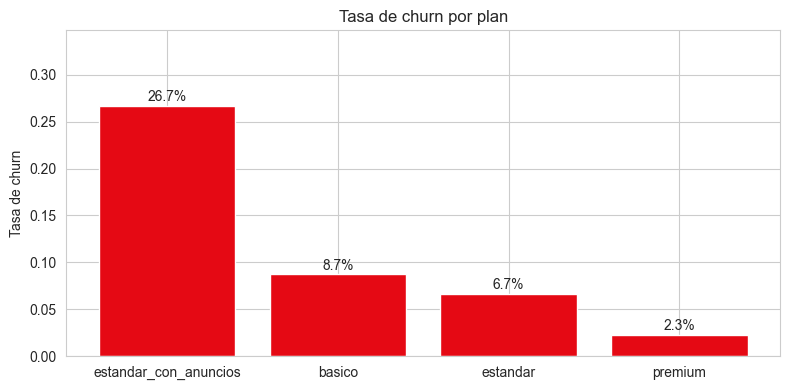

In [5]:
churn_por_plan = df.groupby("plan")["churn_30d"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(churn_por_plan.index, churn_por_plan.values, color=ROJO)
ax.set_ylabel("Tasa de churn")
ax.set_title("Tasa de churn por plan")
ax.set_ylim(0, churn_por_plan.max() * 1.3)
for i, v in enumerate(churn_por_plan.values):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

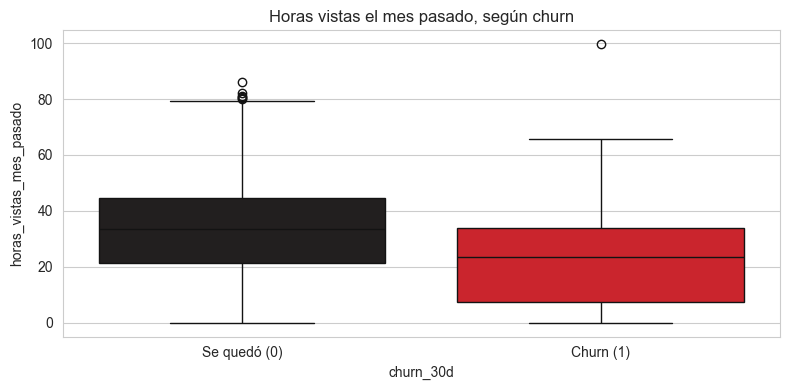

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="churn_30d", y="horas_vistas_mes_pasado",
            hue="churn_30d", palette=[AZUL, ROJO], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Se quedó (0)", "Churn (1)"])
ax.set_title("Horas vistas el mes pasado, según churn")
plt.tight_layout()
plt.show()

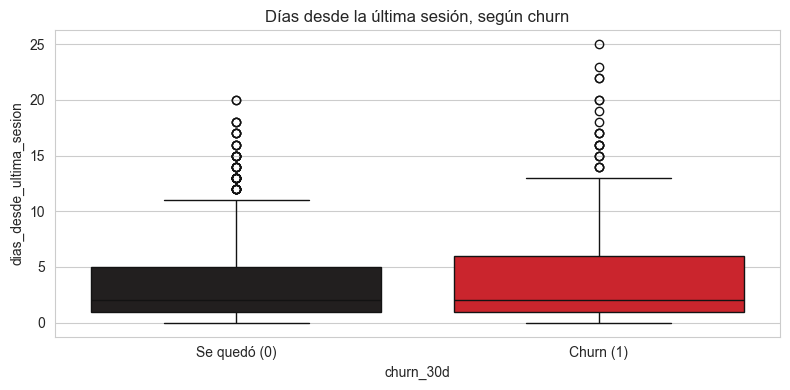

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="churn_30d", y="dias_desde_ultima_sesion",
            hue="churn_30d", palette=[AZUL, ROJO], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Se quedó (0)", "Churn (1)"])
ax.set_title("Días desde la última sesión, según churn")
plt.tight_layout()
plt.show()

**Observaciones del EDA:**

- `estandar_con_anuncios` concentra la mayoría del churn — es el plan más barato y el menos comprometido.
- Los churners venían viendo **menos horas** y con **mayor recencia** (más días sin entrar). Estas dos van a ser las variables más fuertes en el árbol.
- **Outliers en el boxplot de horas:** los puntos altos son binge-watchers reales (90+ horas/mes). Distinto a lo que vimos en Clase 04 con regresión lineal, **CART es robusto a outliers** porque corta por umbrales — no los removemos.

**Vistazo completo:** estadísticas de todas las variables, numéricas y categóricas, para tenerlas a mano.

In [8]:
df.describe().round(2)

,antiguedad_meses,horas_vistas_mes_pasado,perfiles_activos,dias_desde_ultima_sesion,cambios_plan_ultimo_anio,churn_30d,horas_proximo_mes
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,29.78,32.40,1.93,3.54,0.48,0.12,30.34
std,16.70,17.36,1.00,3.96,0.77,0.33,19.98
min,1.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,15.00,19.40,1.00,1.00,0.00,0.00,14.50
50%,29.00,32.20,2.00,2.00,0.00,0.00,29.45
75%,44.00,43.92,2.00,5.00,1.00,0.00,43.50
max,59.00,99.60,5.00,25.00,3.00,1.00,97.10


---
## 3. De los datos al modelo

Solo dos pasos: **one-hot encoding** de las categóricas y **train/test split** estratificado. CART no necesita escalado.

In [9]:
df_modelo = pd.get_dummies(
    df,
    columns=["plan", "genero_favorito", "dispositivo_principal"],
    drop_first=True,
)
df_modelo["usa_descargas_offline"] = df_modelo["usa_descargas_offline"].astype(int)

print(f"Columnas después del one-hot: {df_modelo.shape[1]}")
df_modelo.head()

Columnas después del one-hot: 21


,antiguedad_meses,horas_vistas_mes_pasado,perfiles_activos,usa_descargas_offline,dias_desde_ultima_sesion,cambios_plan_ultimo_anio,churn_30d,horas_proximo_mes,plan_estandar,plan_estandar_con_anuncios,...,genero_favorito_anime,genero_favorito_comedia,genero_favorito_documental,genero_favorito_drama,genero_favorito_kids,genero_favorito_reality,dispositivo_principal_consola,dispositivo_principal_pc,dispositivo_principal_smart_tv,dispositivo_principal_tablet
0,27,37.0,2,0,3,1,0,34.0,True,False,...,False,False,True,False,False,False,False,True,False,False
1,2,6.9,1,1,6,0,1,3.3,False,False,...,True,False,False,False,False,False,False,False,False,False
2,40,45.8,4,1,8,0,0,33.8,False,False,...,False,True,False,False,False,False,False,False,True,False
3,27,23.2,1,1,0,0,0,30.0,True,False,...,False,False,False,False,False,False,False,False,False,False
4,46,17.7,1,0,1,0,0,16.0,False,True,...,False,False,False,False,False,True,False,False,True,False


In [10]:
features = [c for c in df_modelo.columns if c not in ["churn_30d", "horas_proximo_mes"]]

X = df_modelo[features]
y_clf = df_modelo["churn_30d"]
y_reg = df_modelo["horas_proximo_mes"]

X_train, X_test, yclf_train, yclf_test, yreg_train, yreg_test = train_test_split(
    X, y_clf, y_reg, test_size=0.30, random_state=42, stratify=y_clf
)

print(f"Train: {X_train.shape[0]} filas  |  Test: {X_test.shape[0]} filas")

Train: 1050 filas  |  Test: 450 filas


---
## 4. Parte A — Clasificación: ¿quién va a hacer churn?

Árbol con profundidad limitada para que las reglas sean legibles. `class_weight="balanced"` porque solo el 12% son churners.

In [11]:
arbol_clf = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=15,
    class_weight="balanced",
    random_state=42,
)
arbol_clf.fit(X_train, yclf_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=3,
                       min_samples_leaf=15, random_state=42)

In [12]:
yclf_pred = arbol_clf.predict(X_test)

print("Matriz de confusión:")
print(confusion_matrix(yclf_test, yclf_pred))
print("\nReporte de clasificación:")
print(classification_report(yclf_test, yclf_pred, target_names=["Se queda", "Churn"]))

print(f"Accuracy train: {arbol_clf.score(X_train, yclf_train):.3f}   |   Accuracy test: {arbol_clf.score(X_test, yclf_test):.3f}")

Matriz de confusión:
[[277 118]
 [ 11  44]]

Reporte de clasificación:
              precision    recall  f1-score   support

    Se queda       0.96      0.70      0.81       395
       Churn       0.27      0.80      0.41        55

    accuracy                           0.71       450
   macro avg       0.62      0.75      0.61       450
weighted avg       0.88      0.71      0.76       450

Accuracy train: 0.702   |   Accuracy test: 0.713


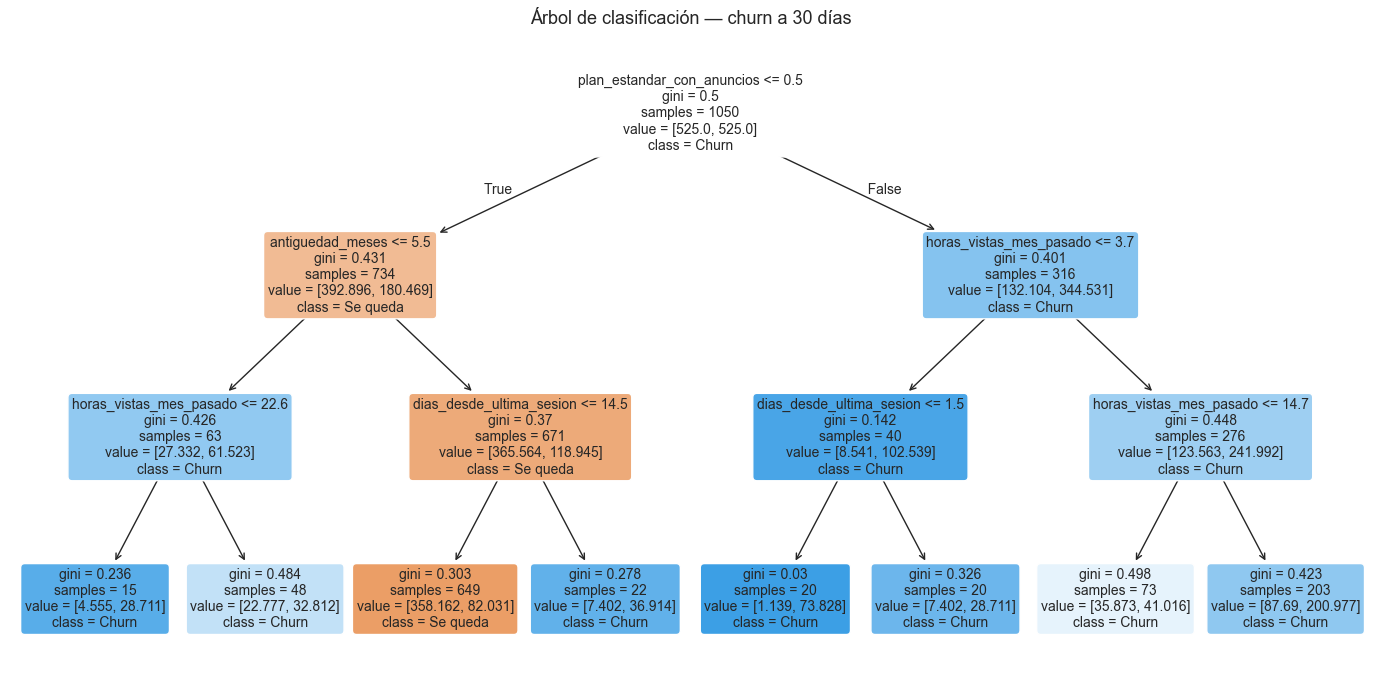

In [13]:
fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(
    arbol_clf,
    feature_names=features,
    class_names=["Se queda", "Churn"],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
)
ax.set_title("Árbol de clasificación — churn a 30 días", fontsize=13)
plt.tight_layout()
plt.show()

**Lectura del árbol:**

- El primer corte lo define `dias_desde_ultima_sesion`: **la recencia es el predictor más fuerte**.
- Las hojas más oscuras del lado Churn son los segmentos prioritarios para el equipo de Retention.

**¿Qué variables pesaron más?** El árbol no usa todas las features por igual — la importancia mide cuánto peso tuvo cada una al armar los cortes.

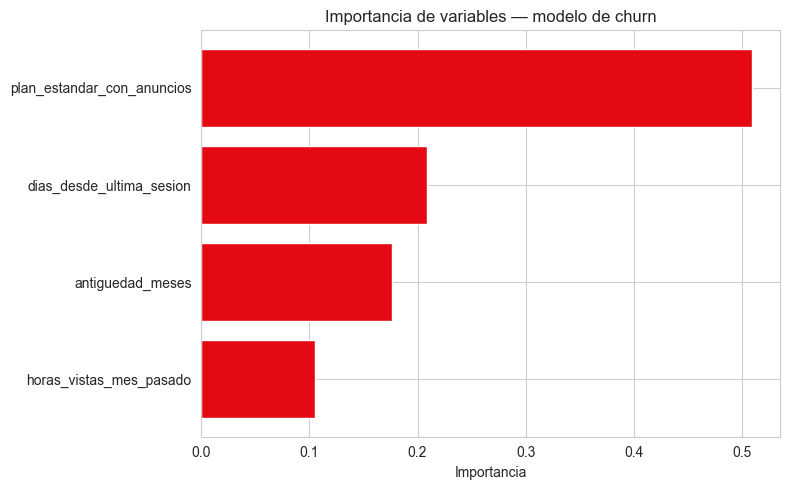

In [14]:
importancias = pd.Series(arbol_clf.feature_importances_, index=features).sort_values(ascending=True)
importancias = importancias[importancias > 0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importancias.index, importancias.values, color=ROJO)
ax.set_title("Importancia de variables — modelo de churn")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

**Las mismas reglas en texto.** Si Retention te pide "pasame el árbol para copiar a un documento", `export_text` te lo devuelve listo.

In [15]:
reglas = export_text(arbol_clf, feature_names=features)
print(reglas)

|--- plan_estandar_con_anuncios <= 0.50
|   |--- antiguedad_meses <= 5.50
|   |   |--- horas_vistas_mes_pasado <= 22.60
|   |   |   |--- class: 1
|   |   |--- horas_vistas_mes_pasado >  22.60
|   |   |   |--- class: 1
|   |--- antiguedad_meses >  5.50
|   |   |--- dias_desde_ultima_sesion <= 14.50
|   |   |   |--- class: 0
|   |   |--- dias_desde_ultima_sesion >  14.50
|   |   |   |--- class: 1
|--- plan_estandar_con_anuncios >  0.50
|   |--- horas_vistas_mes_pasado <= 3.70
|   |   |--- dias_desde_ultima_sesion <= 1.50
|   |   |   |--- class: 1
|   |   |--- dias_desde_ultima_sesion >  1.50
|   |   |   |--- class: 1
|   |--- horas_vistas_mes_pasado >  3.70
|   |   |--- horas_vistas_mes_pasado <= 14.70
|   |   |   |--- class: 1
|   |   |--- horas_vistas_mes_pasado >  14.70
|   |   |   |--- class: 1



---
## 5. Parte B — Regresión: ¿cuántas horas va a ver?

Mismo árbol, target continuo: `DecisionTreeRegressor`. Cambia la métrica interna (MSE en vez de Gini) y la salida (un valor numérico por hoja en vez de una clase).

In [16]:
arbol_reg = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=30,
    random_state=42,
)
arbol_reg.fit(X_train, yreg_train)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=30, random_state=42)

In [17]:
yreg_pred = arbol_reg.predict(X_test)

mse = mean_squared_error(yreg_test, yreg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yreg_test, yreg_pred)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f} horas")
print(f"R2:   {r2:.3f}")

print(f"\nR² train: {arbol_reg.score(X_train, yreg_train):.3f}   |   R² test: {arbol_reg.score(X_test, yreg_test):.3f}")

MSE:  125.77
RMSE: 11.21 horas
R2:   0.687

R² train: 0.689   |   R² test: 0.687


**Visualicemos el árbol de regresión.** Cada hoja es un segmento de consumo con un valor esperado de horas para el próximo mes.

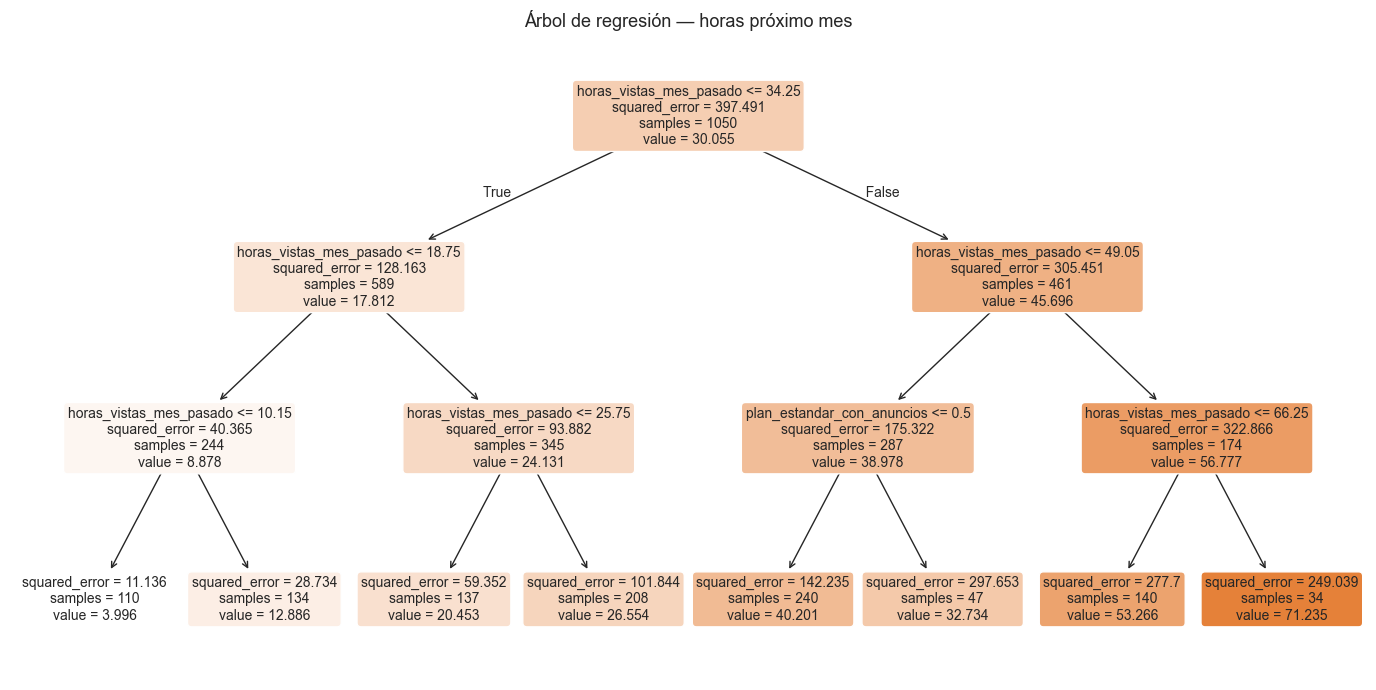

In [18]:
fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(
    arbol_reg,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
)
ax.set_title("Árbol de regresión — horas próximo mes", fontsize=13)
plt.tight_layout()
plt.show()

Las hojas son insumo directo para el cálculo de **LTV por segmento** y para que el equipo de Contenido sepa cuántas horas-vista empujar en cada cohorte.

---
## 6. Cierre

**Respondimos las dos preguntas con las que abrimos la clase:**

### 1. ¿Quién se da de baja en los próximos 30 días?

El clasificador identifica al **80% de los churners reales** (recall 0.80). De cada 100 usuarios que marca como riesgo, ~27 lo son efectivamente (precision 0.27). El modelo no overfittea: accuracy train ≈ accuracy test.

**Acción de Retention:** contactar al subconjunto identificado. Aceptamos los falsos positivos porque el costo de un cupón es bajo, mientras que el costo de no detectar a un churner real es perder el LTV completo del cliente.

### 2. ¿Cuántas horas va a ver el próximo mes?

El regresor predice con **RMSE ~11 horas** y **R² 0.69**. Tampoco overfittea: R² train ≈ R² test. Cada hoja del árbol es un segmento de consumo con un valor esperado de horas.

**Acción de Pricing / Content / Finance:** dimensionar planes por cohorte, planificar inversión en producción de contenido, calcular LTV por segmento.

---

**Por qué CART y no otro modelo:** la diferencia frente a Logística o KNN no es la accuracy — es la **defendibilidad**. Cada predicción del árbol es una secuencia de reglas explícitas. Cuando el CFO pregunta *"¿por qué llamamos a Juan?"*, la respuesta es: *"porque hace 22 días que no entra y su plan es el más barato"*. Eso convierte al modelo en un manual operativo, no en una caja negra.

**Próximo paso:** con `max_depth=3` priorizamos legibilidad sobre máxima performance. La industria combina cientos de árboles (Random Forest, Gradient Boosting) para subir el recall y bajar el error sin perder gran parte de la interpretabilidad. **Eso viene la próxima clase.**